# UMAP Analysis of PM2.5 Input Feature Space

Non-linear dimensionality reduction to identify distinct regimes in the input space.
Uses the tmax-corrected dataset and the same feature set as the SVGP model.

1. Are there distinct clusters/regimes in the input space?
2. What separates them — geography, season, meteorology?
3. How does PM2.5 distribute across the embedding?

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load tmax-corrected data
pm_all = pd.read_csv('../../data/pm25_data_complete_2003_2021_smogI_tmax_corrected_032726.csv', low_memory=False)
pm_fixed = pd.read_csv('../pm25_locs_with_states.csv')

pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')

time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']

pm_subset = pm_all[['ll_id', 'date', 'pm25'] + time_varying_features].copy()
static_df = pm_fixed[['ll_id', 'state'] + static_features].copy()
df = pm_subset.merge(static_df, on='ll_id', how='left')
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

feature_cols = time_varying_features + static_features + ['day_of_year']
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()

print(f'Observations: {len(df_clean):,}')
print(f'Sites: {df_clean["ll_id"].nunique()}')
print(f'States: {df_clean["state"].nunique()}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Observations: 1,883,144
Sites: 932
States: 15
Features (17): ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing', 'day_of_year']


In [2]:
# Stratified subsample: equal per state x season for balanced representation
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
df_clean['season'] = df_clean['month'].map(season_map)

n_target = 75000
rng = np.random.RandomState(42)

# Stratify by state x season
groups = df_clean.groupby(['state', 'season'])
n_groups = len(groups)
per_group = max(1, n_target // n_groups)

sampled_indices = []
for name, group in groups:
    n_sample = min(per_group, len(group))
    sampled_indices.append(group.sample(n=n_sample, random_state=42).index)

sample_idx = np.concatenate(sampled_indices)
rng.shuffle(sample_idx)
df_sample = df_clean.loc[sample_idx].copy()

print(f'Sampled {len(df_sample):,} observations (target: {n_target:,})')
print(f'Per state:')
print(df_sample['state'].value_counts().to_string())

Sampled 71,715 observations (target: 75,000)
Per state:
state
CA    5000
WY    5000
TX    5000
NM    5000
UT    5000
ID    5000
WA    5000
AZ    5000
NV    5000
MT    5000
ND    5000
OR    5000
SD    5000
CO    5000
NE    1715


In [3]:
# defaults
n_neighbors = 40
min_dist = 0.2

# Standardize and run UMAP
X_sample = df_sample[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print(f'Running UMAP (n_neighbors={n_neighbors}, min_dist={min_dist})...')
reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, 
                     metric='euclidean', random_state=42, n_jobs=-1)
embedding = reducer.fit_transform(X_scaled)
print(f'Embedding shape: {embedding.shape}')

df_sample['umap_1'] = embedding[:, 0]
df_sample['umap_2'] = embedding[:, 1]

Running UMAP (n_neighbors=40, min_dist=0.2)...
Embedding shape: (71715, 2)


## 1. UMAP Colored by State

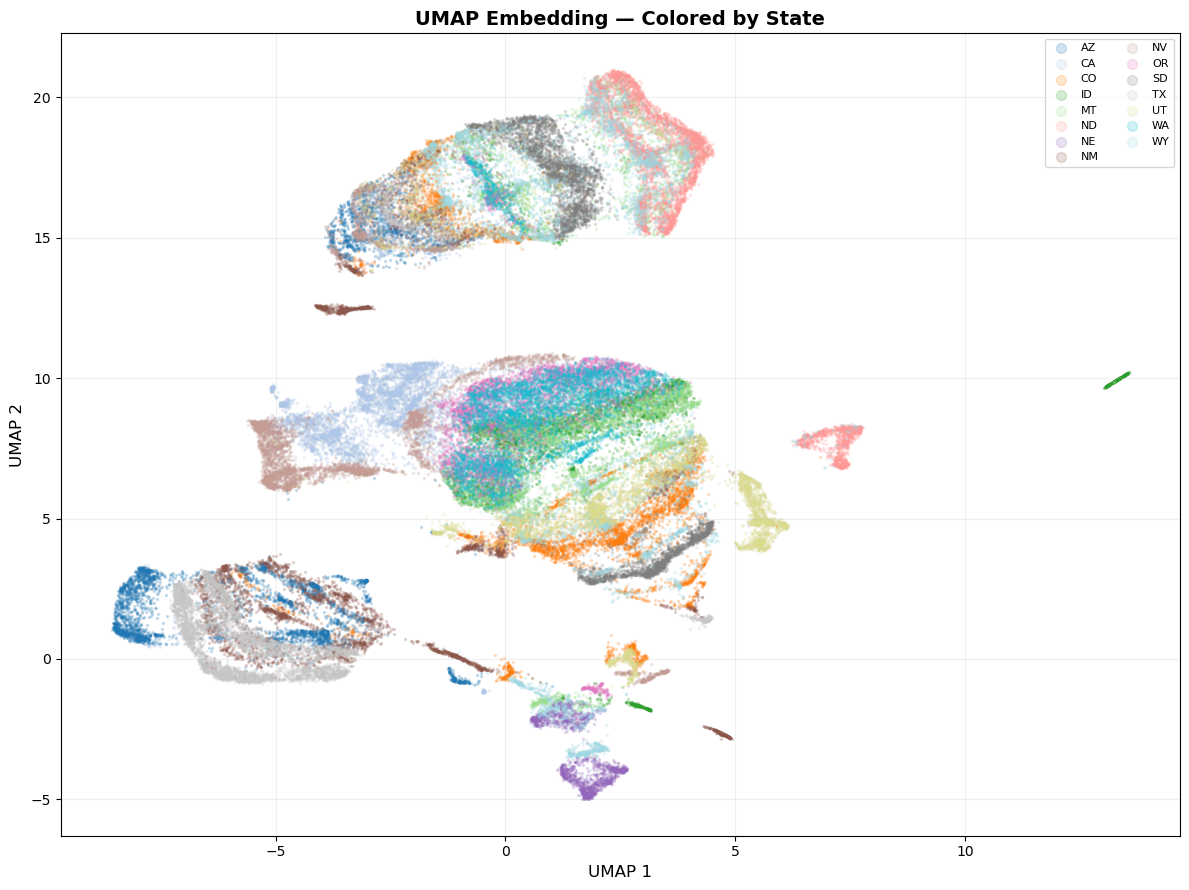

In [4]:
unique_states = sorted(df_sample['state'].unique())
cmap_state = plt.cm.get_cmap('tab20', len(unique_states))
state_colors = {st: cmap_state(i) for i, st in enumerate(unique_states)}

fig, ax = plt.subplots(figsize=(12, 9))
for st in unique_states:
    mask = df_sample['state'] == st
    ax.scatter(embedding[mask, 0], embedding[mask, 1], 
              s=2, alpha=0.2, color=state_colors[st], label=st)
ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP Embedding — Colored by State', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, markerscale=5, ncol=2, loc='best')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('umap_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. UMAP Colored by Season

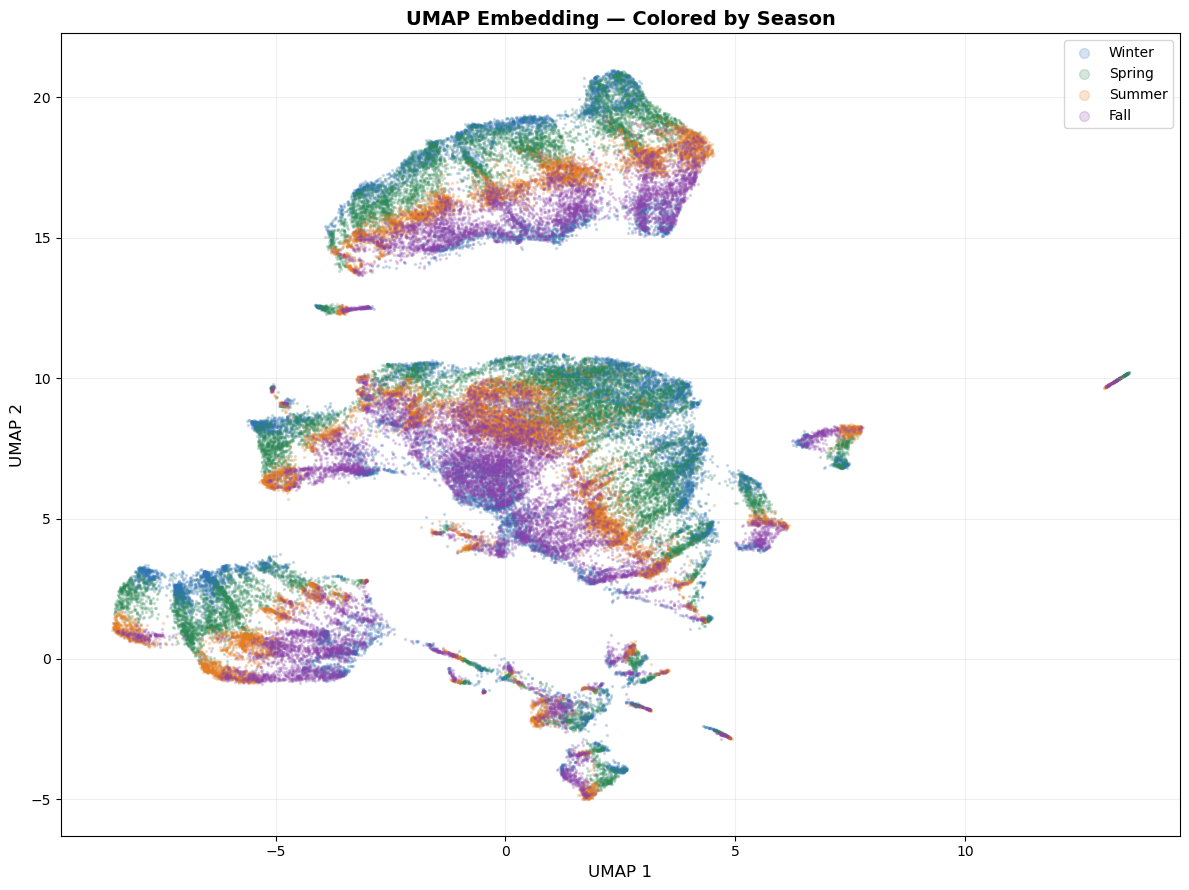

In [5]:
season_colors = {'Winter': '#2E75B6', 'Spring': '#2D8B57', 'Summer': '#E67E22', 'Fall': '#8E44AD'}

fig, ax = plt.subplots(figsize=(12, 9))
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    mask = df_sample['season'] == season
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
              s=2, alpha=0.2, color=season_colors[season], label=season)
ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('UMAP Embedding — Colored by Season', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, markerscale=5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('umap_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. UMAP Colored by PM2.5 and Key Features

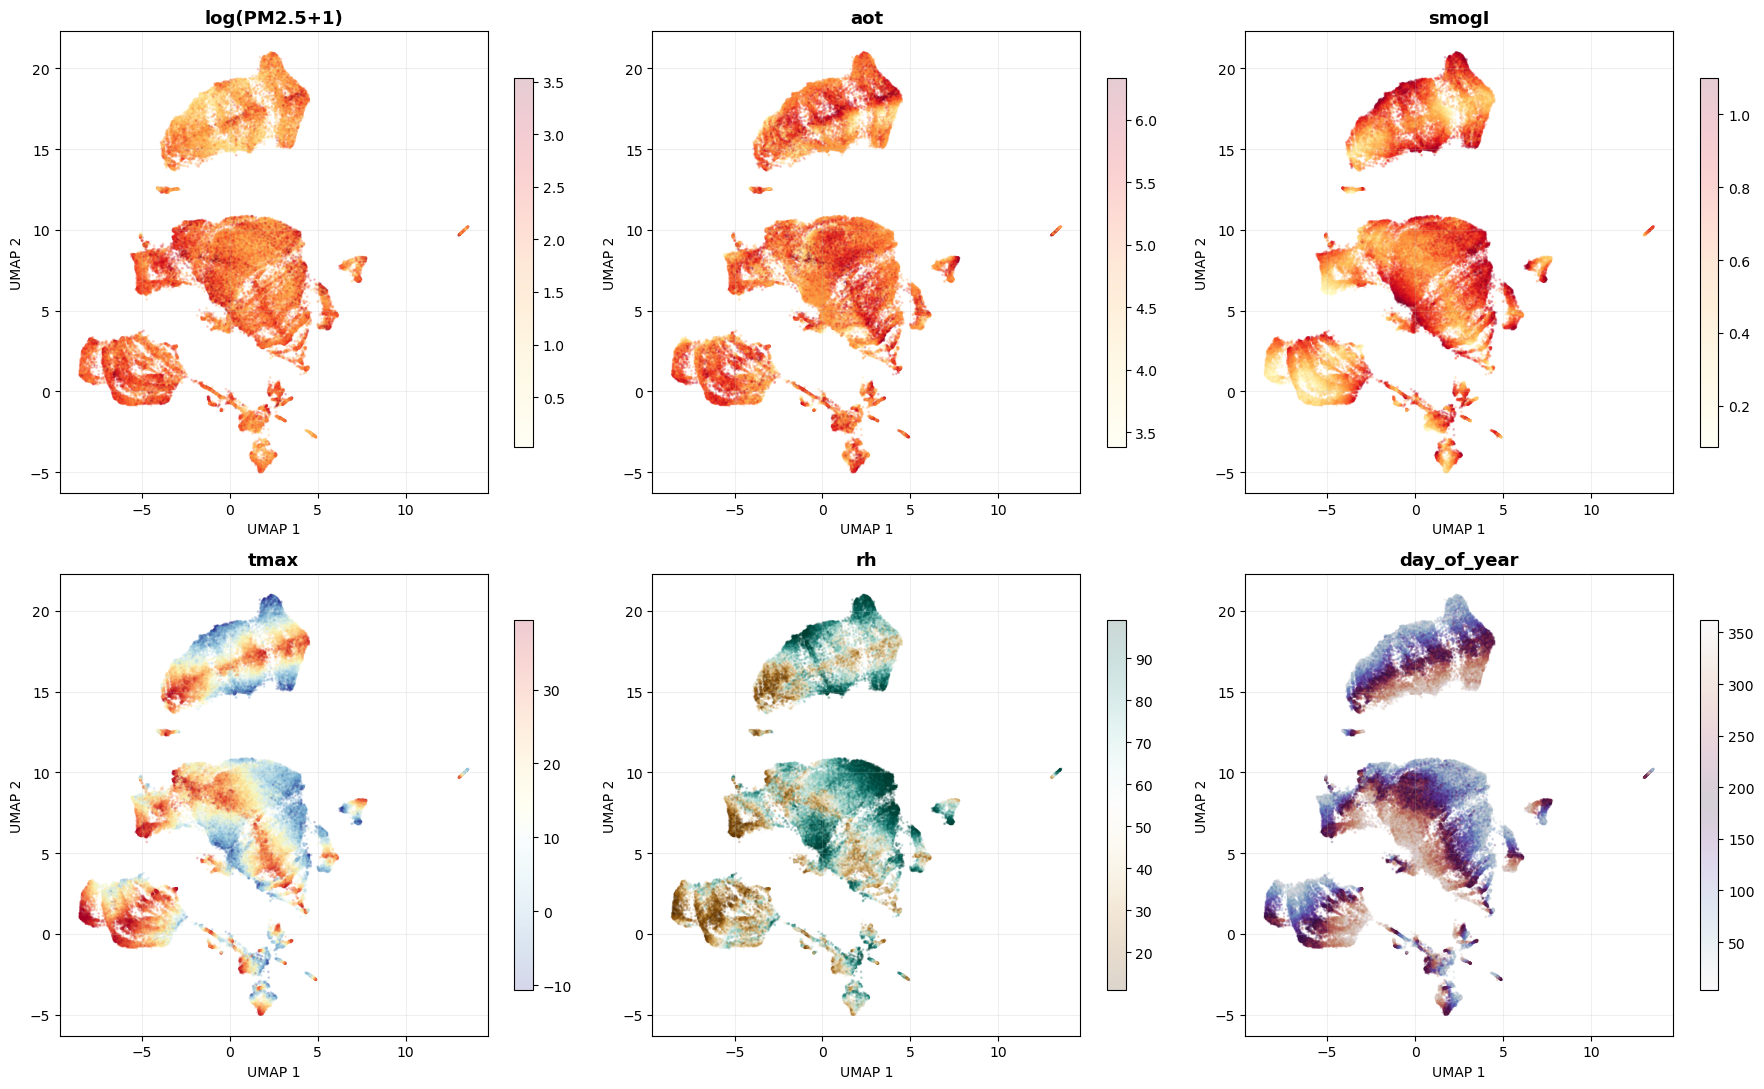

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

color_vars = [
    ('log(PM2.5+1)', np.log(df_sample['pm25'].values + 1), 'YlOrRd'),
    ('aot', df_sample['aot'].values, 'YlOrRd'),
    ('smogI', df_sample['smogI'].values, 'YlOrRd'),
    ('tmax', df_sample['tmax'].values, 'RdYlBu_r'),
    ('rh', df_sample['rh'].values, 'BrBG'),
    ('day_of_year', df_sample['day_of_year'].values, 'twilight'),
]

for ax, (name, values, cmap) in zip(axes.flat, color_vars):
    # Clip to 1st-99th percentile for better color contrast
    vmin, vmax = np.nanpercentile(values, [1, 99])
    sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                   c=values, s=1, alpha=0.2, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. UMAP Colored by Spatial Features

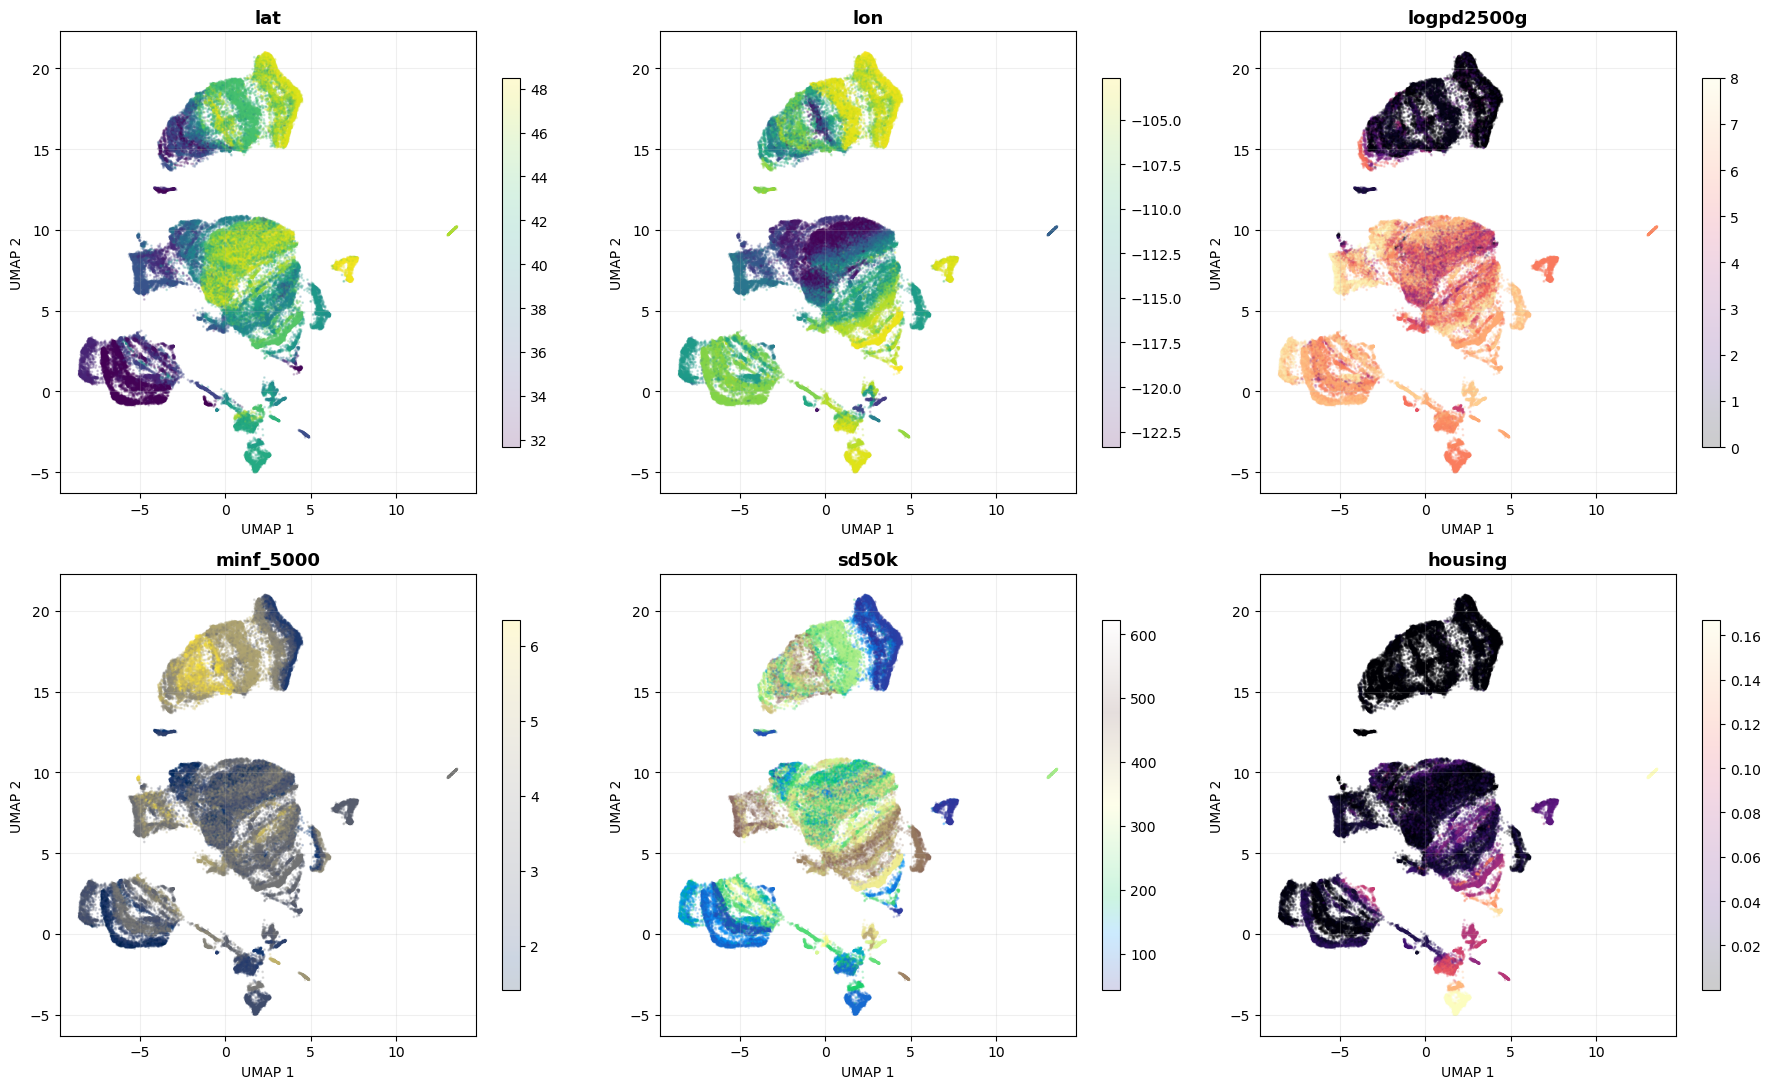

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

spatial_vars = [
    ('lat', df_sample['lat'].values, 'viridis'),
    ('lon', df_sample['lon'].values, 'viridis'),
    ('logpd2500g', df_sample['logpd2500g'].values, 'magma'),
    ('minf_5000', df_sample['minf_5000'].values, 'cividis'),
    ('sd50k', df_sample['sd50k'].values, 'terrain'),
    ('housing', df_sample['housing'].values, 'magma'),
]

for ax, (name, values, cmap) in zip(axes.flat, spatial_vars):
    vmin, vmax = np.nanpercentile(values, [1, 99])
    sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                   c=values, s=1, alpha=0.2, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_by_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. UMAP with Different Parameters

Test sensitivity to `n_neighbors` (local vs global structure).

Running UMAP with n_neighbors=10...


Running UMAP with n_neighbors=30...
Running UMAP with n_neighbors=100...


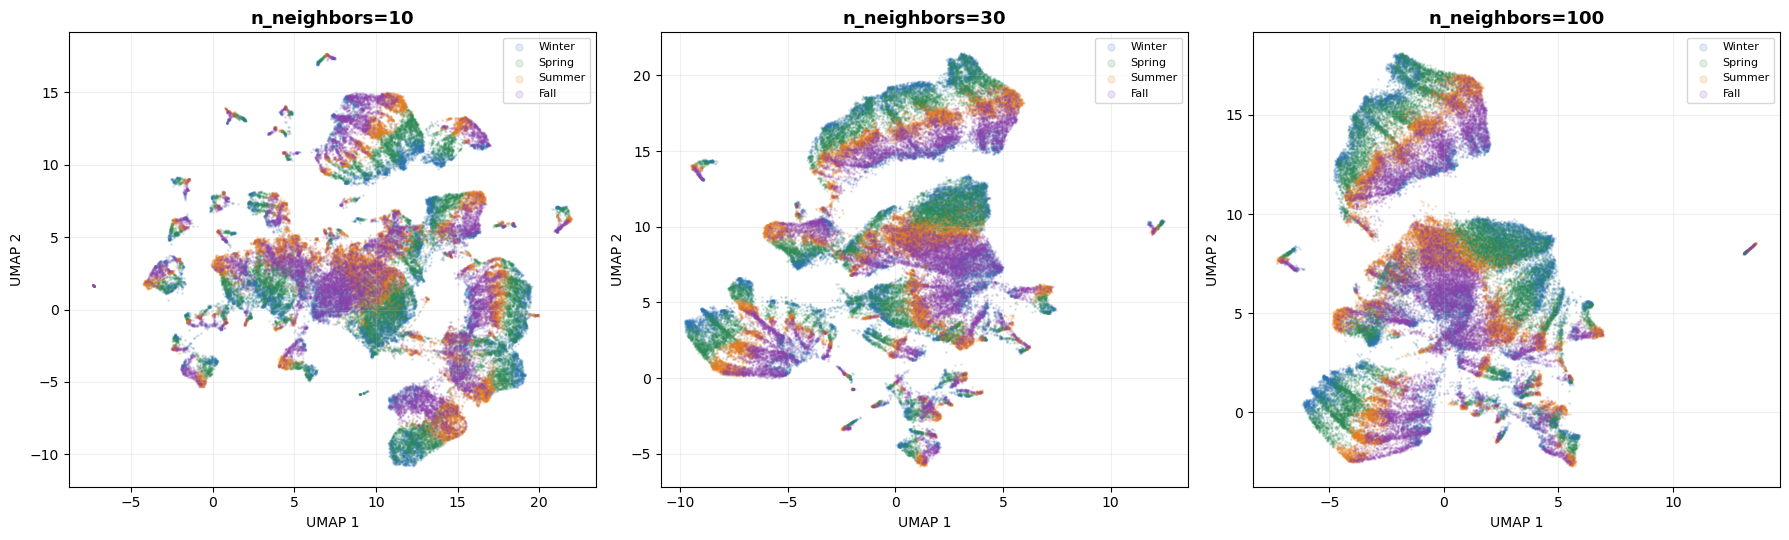

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, n_neigh in zip(axes, [10, 30, 100]):
    print(f'Running UMAP with n_neighbors={n_neigh}...')
    reducer_v = umap.UMAP(n_neighbors=n_neigh, min_dist=0.3, n_components=2,
                          metric='euclidean', random_state=42, n_jobs=-1)
    emb_v = reducer_v.fit_transform(X_scaled)
    
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        mask = df_sample['season'].values == season
        ax.scatter(emb_v[mask, 0], emb_v[mask, 1],
                  s=1, alpha=0.15, color=season_colors[season], label=season)
    ax.set_title(f'n_neighbors={n_neigh}', fontsize=13, fontweight='bold')
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.legend(fontsize=8, markerscale=5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_neighbor_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. High-PM2.5 Events in the Embedding

Do high-PM2.5 observations cluster or are they scattered across regimes?

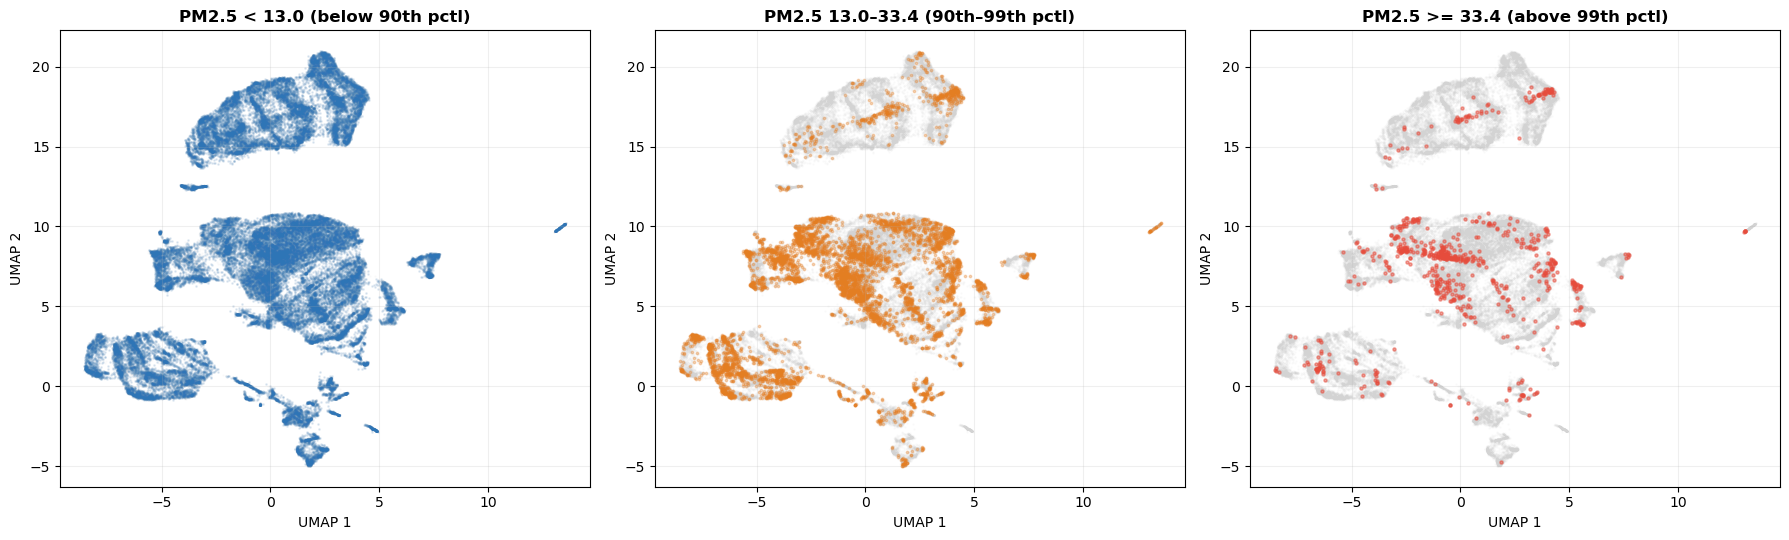

PM2.5 thresholds: 90th=13.0, 99th=33.4
Extreme events (>=99th): 724 observations


In [9]:
pm25_vals = df_sample['pm25'].values
p90 = np.percentile(pm25_vals, 90)
p99 = np.percentile(pm25_vals, 99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# All points (gray background)
for ax in axes:
    ax.scatter(embedding[:, 0], embedding[:, 1], s=1, alpha=0.05, color='lightgray')

# Below 90th percentile
mask_low = pm25_vals < p90
axes[0].scatter(embedding[mask_low, 0], embedding[mask_low, 1],
               s=1, alpha=0.1, color='#2E75B6')
axes[0].set_title(f'PM2.5 < {p90:.1f} (below 90th pctl)', fontsize=12, fontweight='bold')

# 90th-99th percentile
mask_high = (pm25_vals >= p90) & (pm25_vals < p99)
axes[1].scatter(embedding[mask_high, 0], embedding[mask_high, 1],
               s=3, alpha=0.3, color='#E67E22')
axes[1].set_title(f'PM2.5 {p90:.1f}–{p99:.1f} (90th–99th pctl)', fontsize=12, fontweight='bold')

# Above 99th percentile
mask_extreme = pm25_vals >= p99
axes[2].scatter(embedding[mask_extreme, 0], embedding[mask_extreme, 1],
               s=5, alpha=0.5, color='#e74c3c')
axes[2].set_title(f'PM2.5 >= {p99:.1f} (above 99th pctl)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_pm25_extremes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PM2.5 thresholds: 90th={p90:.1f}, 99th={p99:.1f}')
print(f'Extreme events (>=99th): {mask_extreme.sum()} observations')